# Conditional Transformer-Based Generation of 2D Platformer Level Segments

**Student:** Robert Mayfield  
**Dataset:** Video Game Level Corpus (VGLC): Super Mario Bros tile based level files  
**Model:** Conditional decoder-only Transformer with difficulty control tokens

## Project Overview

In [1]:
import json
import pickle
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [2]:
%matplotlib inline

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset Loading and Inspection

In [4]:
def load_level_corpus(data_dir: Path) -> tuple[list[dict], dict]:
    """Load all VGLC level text files and tile specification from a directory.

    Parameters
    ----------
    data_dir : Path
        Directory containing level .txt files and smb.json tile spec.

    Returns
    -------
    levels : list[dict]
        Each dict has keys 'name' (str) and 'rows' (list of str).
    tile_spec : dict
        Tile character to property list mapping from smb.json.
    """
    data_dir = Path(data_dir)

    with open(data_dir / "smb.json") as f:
        tile_spec = json.load(f)["tiles"]

    levels = []
    for path in sorted(data_dir.glob("mario-*.txt")):
        with open(path) as f:
            rows = [line.rstrip("\n") for line in f.readlines()]
        levels.append({"name": path.stem, "rows": rows})

    return levels, tile_spec


DATA_DIR = Path("../data/raw")
levels, tile_spec = load_level_corpus(DATA_DIR)
print(f"Loaded {len(levels)} levels")
print(f"Tile vocabulary: {len(tile_spec)} tile types")

Loaded 15 levels
Tile vocabulary: 13 tile types


In [5]:
def inspect_level_corpus(levels: list[dict]) -> pd.DataFrame:
    """Return a DataFrame of per-level structural statistics.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    pd.DataFrame
        One row per level: name, rows, cols, total_tiles.
    """
    records = []
    for lvl in levels:
        row_count = len(lvl["rows"])
        col_count = max(len(r) for r in lvl["rows"]) if lvl["rows"] else 0
        records.append({
            "name": lvl["name"],
            "rows": row_count,
            "cols": col_count,
            "total_tiles": row_count * col_count,
        })
    return pd.DataFrame(records)


corpus_stats = inspect_level_corpus(levels)
print(corpus_stats.to_string(index=False))
print(f"\nRow height consistent: {corpus_stats['rows'].nunique() == 1} ({corpus_stats['rows'].iloc[0]} rows)")
print(f"Width range: {corpus_stats['cols'].min()} to {corpus_stats['cols'].max()} columns")
print(f"Total tiles in corpus: {corpus_stats['total_tiles'].sum():,}")

     name  rows  cols  total_tiles
mario-1-1    14   202         2828
mario-1-2    14   158         2212
mario-1-3    14   150         2100
mario-2-1    14   197         2758
mario-3-1    14   197         2758
mario-3-3    14   149         2086
mario-4-1    14   222         3108
mario-4-2    14   187         2618
mario-5-1    14   198         2772
mario-5-3    14   150         2100
mario-6-1    14   184         2576
mario-6-2    14   215         3010
mario-6-3    14   165         2310
mario-7-1    14   176         2464
mario-8-1    14   373         5222

Row height consistent: True (14 rows)
Width range: 149 to 373 columns
Total tiles in corpus: 40,922


In [6]:
def display_level(level: dict, max_cols: int = 80) -> None:
    """Print a level tile grid to stdout, truncated to max_cols width.

    Parameters
    ----------
    level : dict
        Level dict with keys 'name' and 'rows'.
    max_cols : int
        Maximum columns to display. Default 80.
    """
    n_rows = len(level["rows"])
    n_cols = len(level["rows"][0]) if level["rows"] else 0
    print(f"  {level['name']}  ({n_rows} rows x {n_cols} cols)")
    print("  " + "-" * min(max_cols, n_cols))
    for row in level["rows"]:
        print("  " + row[:max_cols])


print("Sample levels (first 80 columns):\n")
display_level(levels[0])
print()
display_level(levels[7])

Sample levels (first 80 columns):

  mario-1-1  (14 rows x 202 cols)
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  ----------------------Q---------------------------------------------------------
  --------------------------------------------------------------------------------
  -------------------------------------------------------------------------------E
  ----------------------------------------------------------------S---------------
  ----------------Q---S?SQS---------------------<>---------<>------------------S?S
  ----------------

In [7]:
def count_tile_frequencies(levels: list[dict]) -> Counter:
    """Count each tile character across the full corpus.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    Counter
        Tile character to total count across all levels.
    """
    counts = Counter()
    for lvl in levels:
        for row in lvl["rows"]:
            counts.update(row)
    return counts


tile_counts = count_tile_frequencies(levels)
total_tiles = sum(tile_counts.values())

print(f"{'Tile':<6} {'Count':>8} {'Pct':>8}  Properties")
print("-" * 55)
for ch, count in tile_counts.most_common():
    props = ", ".join(tile_spec.get(ch, ["unknown"]))
    print(f"  {repr(ch):<4} {count:>8,} {count / total_tiles * 100:>7.2f}%  {props}")

Tile      Count      Pct  Properties
-------------------------------------------------------
  '-'    35,277   86.21%  passable, empty
  'X'     3,600    8.80%  solid, ground
  'S'       932    2.28%  solid, breakable
  'E'       275    0.67%  enemy, damaging, hazard, moving
  '['       186    0.45%  solid, left pipe, pipe
  ']'       186    0.45%  solid, right pipe, pipe
  'o'       166    0.41%  coin, collectable, passable
  '<'        85    0.21%  solid, top-left pipe, pipe
  '>'        85    0.21%  solid, top-right pipe, pipe
  'Q'        70    0.17%  solid, question block, empty question block
  '?'        31    0.08%  solid, question block, full question block
  'B'        16    0.04%  Cannon top, cannon, solid, hazard
  'b'        13    0.03%  Cannon bottom, cannon, solid


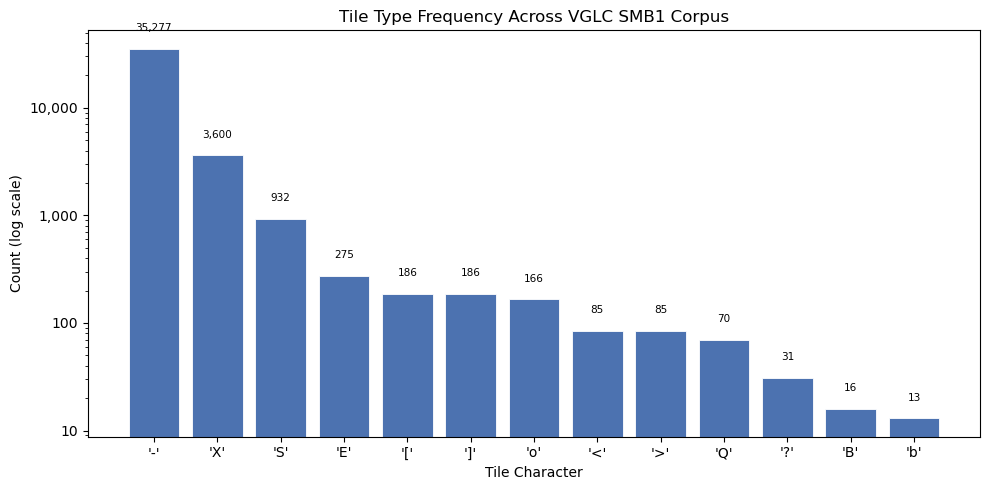

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

tile_labels = [repr(ch) for ch, _ in tile_counts.most_common()]
tile_values = [count for _, count in tile_counts.most_common()]

bars = ax.bar(tile_labels, tile_values, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Tile Type Frequency Across VGLC SMB1 Corpus")
ax.set_xlabel("Tile Character")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, tile_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val * 1.4,
        f"{val:,}", ha="center", va="bottom", fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("../outputs/figures/tile_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=== ROW LENGTH CONSISTENCY ===")
for lvl in levels:
    lengths = [len(r) for r in lvl["rows"]]
    min_l, max_l = min(lengths), max(lengths)
    flag = "" if min_l == max_l else " <-- RAGGED"
    print(f"{lvl['name']}: min={min_l}, max={max_l}, consistent={min_l == max_l}{flag}")

print()
print("=== INVALID CHARACTERS ===")
valid_chars = set(tile_spec.keys())
for lvl in levels:
    chars = set(c for r in lvl["rows"] for c in r)
    invalid = chars - valid_chars
    status = f"invalid: {invalid}" if invalid else "clean"
    print(f"{lvl['name']}: {status}")

print()
print("=== EMPTY ROWS ===")
for lvl in levels:
    empty = [i for i, r in enumerate(lvl["rows"]) if len(r) == 0]
    status = f"empty at rows {empty}" if empty else "none"
    print(f"{lvl['name']}: {status}")


=== ROW LENGTH CONSISTENCY ===
mario-1-1: min=202, max=202, consistent=True
mario-1-2: min=158, max=158, consistent=True
mario-1-3: min=150, max=150, consistent=True
mario-2-1: min=197, max=197, consistent=True
mario-3-1: min=197, max=197, consistent=True
mario-3-3: min=149, max=149, consistent=True
mario-4-1: min=222, max=222, consistent=True
mario-4-2: min=187, max=187, consistent=True
mario-5-1: min=198, max=198, consistent=True
mario-5-3: min=150, max=150, consistent=True
mario-6-1: min=184, max=184, consistent=True
mario-6-2: min=215, max=215, consistent=True
mario-6-3: min=165, max=165, consistent=True
mario-7-1: min=176, max=176, consistent=True
mario-8-1: min=373, max=373, consistent=True

=== INVALID CHARACTERS ===
mario-1-1: clean
mario-1-2: clean
mario-1-3: clean
mario-2-1: clean
mario-3-1: clean
mario-3-3: clean
mario-4-1: clean
mario-4-2: clean
mario-5-1: clean
mario-5-3: clean
mario-6-1: clean
mario-6-2: clean
mario-6-3: clean
mario-7-1: clean
mario-8-1: clean

=== EMPTY 

The corpus contains 15 overworld platformer levels from Super Mario Bros, totaling 40,922 tiles. All levels share a consistent height of 14 rows, while widths range from 149 to 373 columns. The outlier is mario-8-1 at 373 columns, roughly twice the width of the average level, reflecting its role as the final world's extended gauntlet stage.

Tile distribution is heavily skewed toward the empty sky tile (`-`), which accounts for 86.21% of all tiles. Ground tiles (`X`) are second at 8.80%, followed by breakable blocks (`S`) at 2.28%. Interactive and hazard tiles such as enemies (`E`), pipes, coins, and question blocks together make up less than 3% of the corpus. The log scale on the chart is necessary to make the rarer tile types visible at all.

This extreme imbalance has a direct consequence for training: a model that predicts `-` for every token would achieve roughly 86% token level accuracy without learning any meaningful structure. Evaluation must therefore look beyond raw accuracy to structural validity, diversity, and difficulty alignment. The imbalance also means that rare tiles such as enemies and question blocks are underrepresented in training, which may limit the model's ability to place them correctly in generated output.

Data quality checks confirm the corpus is clean and ready for chunking. All rows within every level are uniform width with no ragged edges, all characters belong to the 13 tile vocabulary with no unexpected symbols, and no empty rows are present. No cleaning or imputation step is required before feature engineering.

## Level Feature Engineering

## Difficulty Scoring and Labeling

## Tokenization and Data Pipeline

## Model Architecture

## Training

## Sample Generation

## Evaluation

## Failure Cases and Error Analysis

## Limitations, Bias, and Responsible Use

## Final Notebook Summary